# 🧠 EMG RMS SVM Training

This notebook implements a **Support Vector Machine (SVM)** classifier using **Root Mean Square (RMS)** feature extraction from 8-channel EMG signals, as is common for real-time control applications.

## 1. Import Libraries and Define Constants

In [6]:
import numpy as np
from constants import WINDOW_SIZE, STRIDE, WINDOW_MS, HP_CUTOFF_FREQ

# --- Sklearn/Utility Imports ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Sklearn SVM Model Import ---
from models import SVMModel
from feature_extraction.rms import preprocess_rms

print("Libraries imported successfully.")

# --- Data Labels and Class Names ---
LABELS = {"rest": 0, "clinched": 1, "spread": 2, "flexion": 3, "extension": 4}
CLASS_NAMES = ["rest", "clinched", "spread", "flexion", "extension"]

# Placeholder for actual data paths
#DATA_FILES = [
#    ("../myo/samples/raymond_arm_90_deg_200hz.csv", LABELS["rest"]),
#    ("../myo/samples/raymond_arm_90_deg_pinch_200hz.csv", LABELS["pinch"]),
#    ("../myo/samples/raymond_arm_down_200hz.csv", LABELS["rest"]),
#    ("../myo/samples/raymond_arm_down_pinch_200hz.csv", LABELS["pinch"])
#]

DATA_FILES = [
    ("../myo/samples/raymond_intervals.csv"),
    #("../myo/samples/josiah_dynamic.csv"),
    #("../myo/samples/josiah_dynamic_violentrest.csv"),
    #("../myo/samples/raymond_behind_back.csv"),
    ("../myo/samples/raymond_spread_finger.csv"),
    ("../myo/samples/raymond_flexion.csv"),
    ("../myo/samples/raymond_extension.csv"),
    ("../myo/samples/raymond_spread_diff_orientation.csv"),
]

Libraries imported successfully.


## 2. Feature Extraction and Model Definition
*(This logic is now defined in `feature_extraction/*`)*

In [2]:
print("Preprocessing functions imported from feature_extraction/")

Preprocessing functions imported from feature_extraction/


## 3. Load, Preprocess, and Split Data

In [3]:
X_all = []
Y_all = []

print(f"Feature extraction parameters: Window size = {WINDOW_MS}ms ({WINDOW_SIZE} samples), High-pass filter = {HP_CUTOFF_FREQ}Hz")
print("Processing all data files (Filter and RMS extraction)...")

#for path, label in DATA_FILES:
#   print(f"Processing file: {path} with label: {label}")
#    # RMS preprocessing is used here
#    X_rms = preprocess_rms(path)
#    
#    if X_rms.size > 0:
#        X_all.append(X_rms)
#        Y_all.append(np.full(X_rms.shape[0], label, dtype=np.int64))

for path in DATA_FILES:
    print(f"Processing file: {path}")

    X_rms, Y_rms = preprocess_rms(path)

    print(X_rms.shape, Y_rms.shape)

    X_all.append(X_rms)
    Y_all.append(Y_rms)

X_all = np.concatenate(X_all)
Y_all = np.concatenate(Y_all)

print(f"Total feature vectors collected: {len(X_all)}")
print(f"Feature vector shape: {X_all.shape} (N_windows, N_channels)")

# Split Data (20% for testing)
X_train, X_test, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=0.2, random_state=42, stratify=Y_all
)

print(f"Training feature vectors: {len(X_train)}")
print(f"Testing feature vectors: {len(X_test)}")

Feature extraction parameters: Window size = 200ms (40 samples), High-pass filter = 10.0Hz
Processing all data files (Filter and RMS extraction)...
Processing file: ../myo/samples/raymond_intervals.csv
Processing label 0 with 10105 samples.
Processing label 1 with 10196 samples.
Processing label 2 with 0 samples.
Processing label 3 with 0 samples.
Processing label 4 with 0 samples.
(1012, 8) (1012,)
Processing file: ../myo/samples/raymond_spread_finger.csv
Processing label 0 with 7703 samples.
Processing label 1 with 0 samples.
Processing label 2 with 7798 samples.
Processing label 3 with 0 samples.
Processing label 4 with 0 samples.
(772, 8) (772,)
Processing file: ../myo/samples/raymond_flexion.csv
Processing label 0 with 8301 samples.
Processing label 1 with 0 samples.
Processing label 2 with 0 samples.
Processing label 3 with 8400 samples.
Processing label 4 with 0 samples.
(833, 8) (833,)
Processing file: ../myo/samples/raymond_extension.csv
Processing label 0 with 9503 samples.
P

## 4. Train and Evaluate SVM Model

In [4]:
# Initialize Model
# Using the default RBF kernel for non-linear separation
model = SVMModel(num_classes=len(LABELS), kernel='rbf') 

# Train Model (Single fit call for SVM)
model.fit(X_train, Y_train)

# Evaluate Model
best_acc, best_preds, best_labels = model.test_epoch(X_test, Y_test)

print("---\n🎉 Training and Testing Complete")
print("Test Accuracy:", best_acc)

# --- Dump the weights in this block ---
# The dump method serializes the entire scikit-learn pipeline (Scaler + SVC)
model.dump("svc_5_agnostic.pkl")

SVM Model Initialized (Kernel: rbf)
Starting SVM training...
SVM training complete.
---
🎉 Training and Testing Complete
Test Accuracy: 1.0
✅ Model saved successfully to: svc_5_agnostic.pkl


## 5. Visualize Results

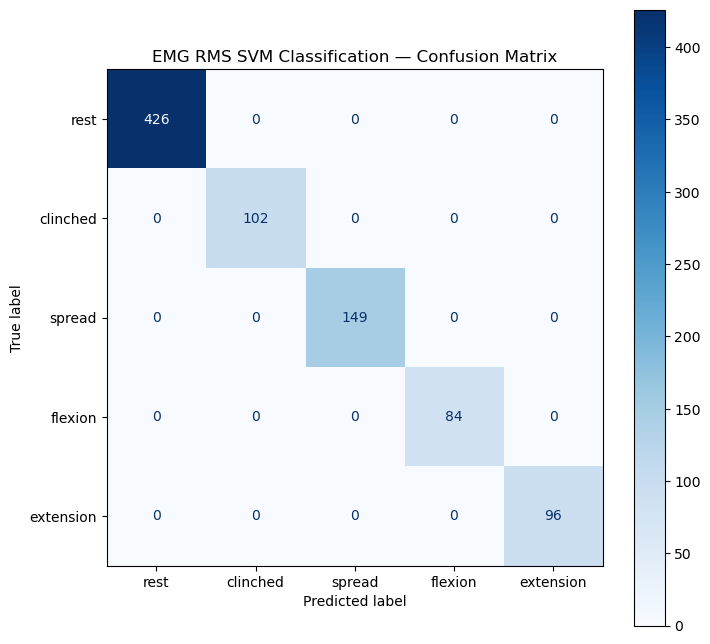

In [7]:
if best_preds is not None and best_labels is not None:
    # Confusion Matrix
    cm = confusion_matrix(best_labels, best_preds, labels=[0, 1, 2, 3, 4])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("EMG RMS SVM Classification — Confusion Matrix")
    plt.show()
else:
    print("Could not generate confusion matrix. Check if training ran successfully.")